# ARIMAモデルによる突発的信号の検出
# — バースト重力波探索のアイデア —

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_arima_burst_search.ipynb)

## はじめに
重力波検出器のデータは定常的なノイズが支配的であり、バースト重力波（超新星爆発等）はこのノイズの中に埋もれた「短時間の非定常信号」として現れます。

本ノートブックでは、**自己回帰モデル（ARIMA）**を用いて「定常ノイズを学習し、残差に突発的信号を浮かび上がらせる」というアイデアを体験します。この手法はテンプレートを必要としない「アンモデル（unmodeled）」探索の基礎的なアプローチの一つです。

### 参考文献
- Autoregressive Search of Gravitational Waves: Denoising (ARIMA_DeNoise.pdf)
- BEACON: Autoregressive Search for Unmodeled transients (BEACON.pdf)
- Sparkler: Autoregressive Search of Unmodeled GW (Sparkler_1min.pdf)


In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from gwexpy.timeseries import TimeSeries
from gwexpy.noise.wave import gaussian, sine, from_asd, colored


## 1. 検出器ノイズの生成
まず、重力波検出器の背景ノイズをシミュレートします。可能であれば LIGO の設計感度（aLIGO）を用い、ライブラリがない場合は一般的な colored noise で代用します。


ノイズモデル: Colored noise (f^{-0.5})
サンプル数: 65536, dt=0.000244140625 ss, duration=16s


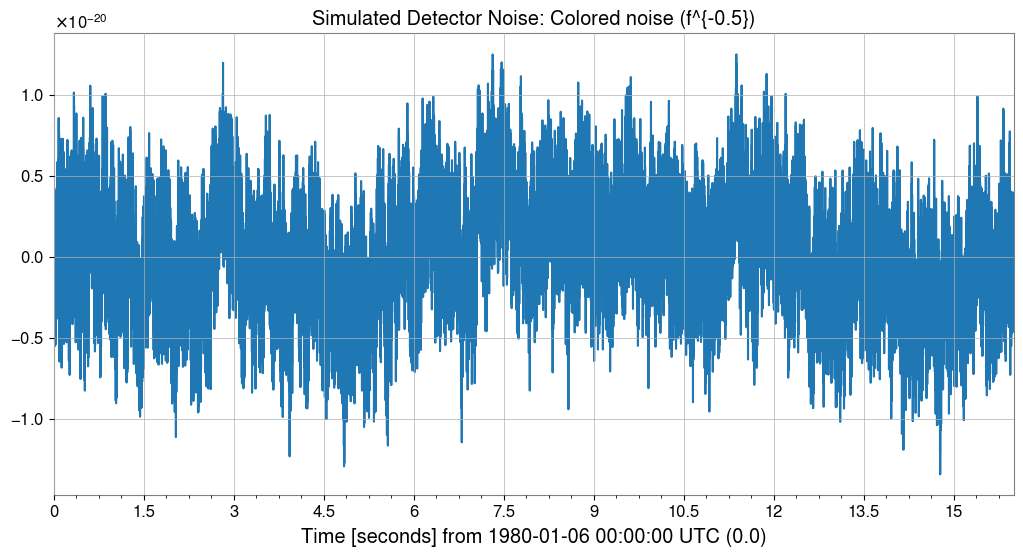

In [2]:
# === パラメータ ===
sample_rate = 4096  # Hz
duration     = 16   # seconds
seed         = 42

# === ノイズ生成 ===
try:
    from gwexpy.noise.gwinc_ import from_pygwinc
    # aLIGO 感度曲線の取得
    asd = from_pygwinc("aLIGO", fmin=10.0, fmax=sample_rate/2, df=1.0/duration)
    # ASD から時系列ノイズを生成
    noise = from_asd(asd, duration=duration, sample_rate=sample_rate, seed=seed,
                     name="aLIGO_noise")
    noise_model_name = "aLIGO (pygwinc)"
except ImportError:
    # pygwinc が無い場合のフォールバック: べき則 colored noise (1/f)
    noise = colored(duration=duration, sample_rate=sample_rate,
                    exponent=0.5, amplitude=1e-21, seed=seed,
                    name="colored_noise")
    noise_model_name = "Colored noise (f^{-0.5})"

print(f"ノイズモデル: {noise_model_name}")
print(f"サンプル数: {len(noise)}, dt={noise.dt}s, duration={duration}s")

noise.plot()
plt.title(f"Simulated Detector Noise: {noise_model_name}")
plt.show()


## 2. バースト信号の注入
テストデータとして、Sine-Gaussian バースト信号をノイズの後半部分に注入します。


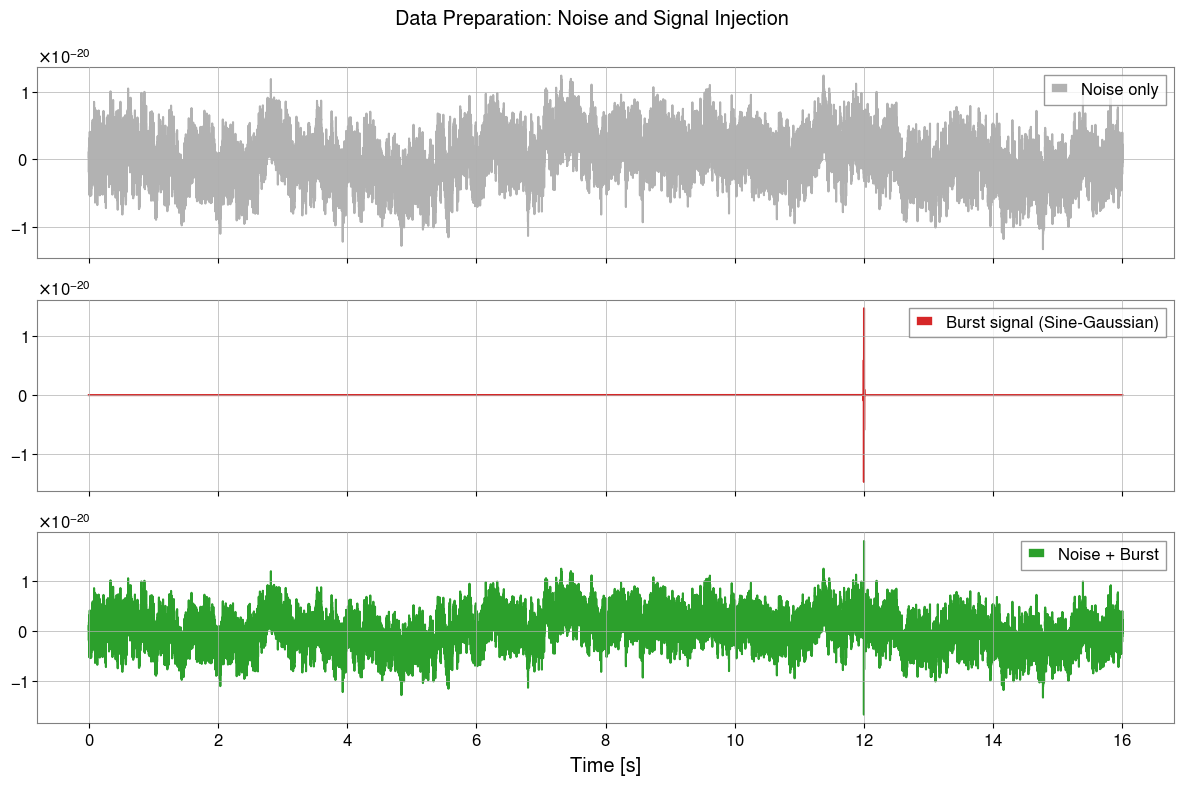

In [3]:
def make_sine_gaussian(duration, sample_rate, t_center, freq, tau, amplitude, t0=0.0):
    """Sine-Gaussian パルスを生成する"""
    t = np.arange(0, duration, 1.0/sample_rate)
    envelope = amplitude * np.exp(-((t - t_center)**2) / (2 * tau**2))
    signal = envelope * np.sin(2 * np.pi * freq * (t - t_center))
    return TimeSeries(signal, sample_rate=sample_rate, t0=t0,
                      name=f"SG_burst_f{freq}_tau{tau}")

# === バースト信号パラメータ ===
burst_time  = 12.0   # 注入時刻（後半 8 秒のどこか）
burst_freq  = 250.0  # Hz
burst_tau   = 0.002  # 秒
# SNR がおよそ 5 程度になるように振幅を調整
std_noise = float(noise.value.std())
burst_amp   = 5.0 * std_noise

burst = make_sine_gaussian(duration, sample_rate, burst_time,
                           burst_freq, burst_tau, burst_amp)

# === 注入 ===
data_with_signal = TimeSeries(
    noise.value + burst.value,
    sample_rate=sample_rate, t0=noise.t0,
    name="data_with_burst"
)

# === 可視化 ===
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(noise, label="Noise only", color="gray", alpha=0.6)
axes[0].legend(loc="upper right")
axes[1].plot(burst, label="Burst signal (Sine-Gaussian)", color="tab:red")
axes[1].legend(loc="upper right")
axes[2].plot(data_with_signal, label="Noise + Burst", color="tab:green")
axes[2].legend(loc="upper right")
plt.suptitle("Data Preparation: Noise and Signal Injection")
plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()


## 3. ARIMAモデルによるノイズ学習
信号が含まれていない前半の 8 秒間を「バックグラウンド区間」とし、ARIMAモデルをフィットさせてノイズの統計的性質を学習させます。
※ 計算コストを抑えるため、適度にダウンサンプルを行います。


In [4]:
# === トレーニングデータの準備 ===
# 最初の 8 秒をトレーニング区間とする
train_end_idx = int(8.0 * sample_rate)

# ダウンサンプル (4096 Hz -> 512 Hz)
downsample_factor = 8
train_data = data_with_signal[:train_end_idx:downsample_factor]

print(f"Training data: {len(train_data)} samples, Fs={train_data.sample_rate} Hz")

# fit_arima: Auto-ARIMA で最適次数を自動選択 (時間は少々かかります)
# ここでは探索範囲を限定して高速化。pmdarima が無い場合は固定次数にフォールバックします。
try:
    result = train_data.fit_arima(auto=True, auto_kwargs={"max_p": 3, "max_q": 3, "seasonal": False})
    print("\nARIMA Fit Summary (Auto-ARIMA):")
except ImportError:
    print("\npmdarima not found. Falling back to fixed order (3, 0, 1).")
    result = train_data.fit_arima(order=(3, 0, 1), trend="c")
    print("\nARIMA Fit Summary (Fixed Order):")

print(result.summary())


Training data: 4096 samples, Fs=512.0 Hz Hz

pmdarima not found. Falling back to fixed order (3, 0, 1).


ImportError: statsmodels is required for ARIMA. `pip install statsmodels`

## 4. 残差の計算と異常検出
学習したモデルを残りのデータ（テスト区間）に適用し、予測値と実データの「残差」を計算します。定常ノイズであれば残差は小さくなりますが、モデルに含まれないバースト信号が存在すると、残差が大きく跳ね上がります。


In [ ]:
# === テストデータへの適用 ===
test_data = data_with_signal[train_end_idx::downsample_factor]

# 学習モデルの次数を適用して残差を求める
order = result.res.model_orders
test_result = test_data.fit_arima(order=(order['ar'], 0, order['ma']), trend="c")
test_resid = test_result.residuals()

# === 閾値判定 (5-sigma) ===
# トレーニング区間の残差の標準偏差から閾値を設定
train_resid = result.residuals()
sigma = float(train_resid.value.std())
threshold = 5.0 * sigma

# トリガー検出
trigger_mask = np.abs(test_resid.value) > threshold

# === 可視化 ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_resid, label="Residuals", color="gray", alpha=0.7)
ax.axhline(threshold, color="red", ls="--", label=f"Detection Threshold (5-sigma)")
ax.axhline(-threshold, color="red", ls="--")

if np.any(trigger_mask):
    t_test = test_resid.times.value
    ax.scatter(t_test[trigger_mask], test_resid.value[trigger_mask],
               color="tab:red", s=40, zorder=5, label="Trigger Detected")

ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.set_title("Search Results: Residuals and Triggers")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.show()


## 5. 性能評価 (SNR 依存性)
異なる SNR (Signal-to-Noise Ratio) で注入を行い、本手法の検出感度を確認します。


In [ ]:
# シンプルなモンテカルロ評価
snr_values = [2, 3, 4, 5, 7, 10]
n_trials = 5
detection_rates = []

# 前回の次数を使用
order_tuple = (order['ar'], 0, order['ma'])

print("Evaluating SNR sensitivity...")
for snr in snr_values:
    hits = 0
    for i in range(n_trials):
        # 新しいノイズ実現
        n_val = colored(duration=4, sample_rate=sample_rate, exponent=0.5, seed=snr*100+i).value
        s_val = make_sine_gaussian(4, sample_rate, 2.0, burst_freq, burst_tau, snr * n_val.std()).value
        trial_ts = TimeSeries(n_val + s_val, sample_rate=sample_rate)[::downsample_factor]
        
        # フィットとチェック
        try:
            res = trial_ts.fit_arima(order=order_tuple)
            if np.any(np.abs(res.residuals().value) > 5.0 * sigma):
                hits += 1
        except:
            continue
    detection_rates.append(hits / n_trials)

plt.figure(figsize=(8, 4))
plt.plot(snr_values, detection_rates, 'o-')
plt.xlabel("Injected SNR")
plt.ylabel("Detection Rate")
plt.title("Sensitivity Curve (Approximation)")
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.show()


## まとめ

### ARIMAモデルによる探索のポイント
1. **ノイズの低減**: 定常的なノイズ（背景波）をモデル化して差し引くことで、微弱な過渡信号を見つけやすくします。
2. **残差解析**: 期待される統計分布（ガウス分布等）からの逸脱を監視することで、未知の信号を捉えます。

実際の探索パイプライン（BEACON等）では、これを多波長や多チャンネルに拡張し、さらにコヒーレンス解析などを組み合わせることで信頼性を高めています。
